# Machine Learning

## Table of Contents
<!-- 
### Part 0 – Global Orientation
- Prediction vs learning vs inference, Classification vs regression, Generative vs discriminative, Prior/likelihood/posterior -->

### Part 1 – Manfred's Topics
- Linear models and decision regions, Overfitting, Least squares regression, LDA, Logistic regression
- Support Vector Machines, Kernels, Kernel trick, String kernels
- Graph kernels – convolution, graphlet, random walk, Weisfeiler-Lehman

### Part 2 – Thomas' Topics
- Neural networks – loss functions, computational graphs, backpropagation, SGD
- Probabilistic graphical models – MLE, EM algorithm, Bayesian learning
- Variational inference – ELBO, mean-field, BBVI, probabilistic programming

### Part 3 – Peter's Topics
- Link prediction with node embeddings – encoder/decoder, matrix factorisation, random-walk methods
- Graph Neural Networks – message passing, normalisation, attention / multi-head attention
- Node and graph classification – iterative classification, aggregations, random-walk classification


<!-- # Part 0 – Global Orientation

## Central pattern

Most methods in the course can be explained as:

1. **Model class:** linear functions, neural networks, SVMs, Bayesian networks, kernels, etc.
2. **Objective:** squared error, likelihood, margin, cross-entropy, ELBO, etc.
3. **Optimisation / inference:** closed-form, gradient descent, EM, variational inference, etc.
4. **Use:** prediction, classification, regression, uncertainty quantification, inference.

## Classification vs regression
- **Classification:** predict a discrete class label.
- **Regression:** predict a continuous value.

## Generative vs discriminative
- **Generative:** models $p(X,Y)=p(Y)p(X|Y)$. Examples: Naive Bayes, LDA.
- **Discriminative:** models $p(Y|X)$ directly. Examples: logistic regression, neural networks.

## Prior, likelihood, posterior

$$p(\theta|D)=\frac{p(\theta)p(D|\theta)}{p(D)}$$

- **Prior** $p(\theta)$: belief before data.
- **Likelihood** $p(D|\theta)$: probability of data under parameter value.
- **Posterior** $p(\theta|D)$: belief after seeing data.
- **Evidence** $p(D)$: normaliser. -->

# Manfred's Topics

# Part 1 Linear Models

**Purpose:**  
Linear models solve regression and classification problems. In regression, the goal is to predict a continuous value, for example house price. In classification, the goal is to predict a class label, for example spam or not spam.

**Model:**  
The basic model is
$$
y = w_0 + w_1 x_1 + ... + w_d x_d
$$
$$
\hat{y} = w^T x + w_0 
$$

where $x$ is the input feature vector, $w$ are weights, and $b$ is a bias. For classification, the linear function defines **decision regions** separated by hyperplanes. In **logistic regression**, the output is transformed into a probability:

$$
P(y=1|x)=\sigma(w^Tx+b)
$$

In **linear discriminant analysis**, each class is modeled by a probability distribution, usually Gaussian.

**Objective:**  
For **least squares regression**, the objective is to minimize squared error:

$$
\sum_i (y_i - \hat{y}_i)^2
$$

For **logistic regression**, the objective is to minimize cross-entropy loss. For LDA, the objective is to find class boundaries using class means and shared covariance structure.

**Learning algorithm:**  
Least squares can be solved analytically or by numerical optimization. Logistic regression is usually learned with gradient-based optimization. LDA estimates class means, class priors, and covariance matrices from the data.

**Assumptions:**  
Linear models assume that the relationship between features and output is approximately linear. Least squares assumes errors are roughly independent and often normally distributed. LDA assumes class distributions are Gaussian with similar covariance matrices.

## 1.1 Decision Regions

> Given a **instance space** (input space): space of all possible values for the input features $x$.
>
> A classifier partitions the instance space into decision regions: each class label $y$ defines the region of points $x$ for which the predicted label will be $y$.

## 1.2 Overfitting

**Key idea:** low training error + high test error = overfitting. Often when model is too complex.

> Given a hypothesis space $H$, a hypothesis $h ∈ H$ is said to overfit
> the training data if there exists some alternative hypothesis $h' ∈ H$,
> such that $h$ has smaller error than $h'$ over the training examples, but
> $h'$ has a smaller error than $h$ over the entire distribution of instances
> [Mitchell, p. 67].

**4-minute structure:**
1. Define training vs test error.
2. Model complexity sweet spot.
3. k-NN: small k = high complexity (overfits), large k = smoother.
4. Regularisation and validation.

## 1.3 Least Squares Regression for Classification

In least squares regression for classification, we solve a classification task as if it were a regression problem.
Each class is represented by a one-hot vector, and the model outputs a score for each class.
The weights are learned by minimizing the sum of squared errors between the predicted scores and the target vectors.
The nice thing is that this has a closed-form solution, so training is straightforward.
The drawback is that squared error does not directly match classification accuracy or class probabilities, so this method is not ideal for classification.

**Model:** 

The **goal** is to find a matrix $\widetilde{W}$ so that given a model $y(x_n) \sim t_n$

For the data $x_n$ with class labels $y_n​∈\{1,…,K\}$. 

We want as an output a $K$-dimesional **target vector** $t_n = (0,...,1,...,0)^T$ which is the called the one hot encoding of $y_n$. 


The goal is to solve minimize the SSE $E_D(\widetilde{W}) = \frac{1}{2}\sum_{n=1}^{N}||\widetilde{W}^T\tilde{x}_n - t_n||^2$ via normal equations the closed form is: $\widetilde{W} = (\widetilde{X}^T\widetilde{X})^{-1}\widetilde{X}^T T$.

**4-minute structure:**
1. One-hot encoding.
2. Squared error objective $E_D(\widetilde{W}) = \frac{1}{2}\sum_{n=1}^{N}||\widetilde{W}^T\tilde{x}_n - t_n||^2$
3. Closed-form normal-equation solution.
5. Limitation: squared error is not classification error.

## 1.4 Linear Discriminant Analysis (LDA)
**Linear Discriminant Analysis (LDA)** is a **generative probabilistic classification model** that assumes the data for each class is generated from a Gaussian distribution and that **all classes share the same covariance matrix**.   

<!-- It works by first modeling the joint distribution $P(Y, X) = P(Y)P(X \mid Y)$, then computing the posterior $P(Y=k \mid X=x)$ using Bayes’ rule and assigning a point to the class with highest probability.   
Because the covariance matrices are identical, the resulting decision boundaries between classes are **linear**, which is why the method is called “linear discriminant.” -->

### Gaussian Mixture Models (GMM)

A Gaussian Mixture Model is a **generative probabilistic model**.  
It models the joint distribution:

$$
P(Y, \mathbf{X}) = P(Y)P(\mathbf{X}|Y)
$$

where:

- $Y$ = class label
- $\mathbf{X}$ = feature vector

The model assumes:

- $P(Y)$ is multinomial (class priors)
- $P(\mathbf{X}|Y=k)$ follows a Gaussian distribution for each class $k$

For each class:

$$
P(\mathbf{X}=\mathbf{x}|Y=k)
=
\frac{1}{(2\pi)^{D/2}|\Sigma_k|^{1/2}}
\exp\left(
-\frac12
(\mathbf{x}-\mu_k)^T
\Sigma_k^{-1}
(\mathbf{x}-\mu_k)
\right)
$$


Each class $k$ has:

- Mean vector: $\mu_k$

- Covariance matrix: $\Sigma_k$

- Prior probability: $P(Y=k)$

The nondiagonal of the covariance matrix represent how much is tilted, if positive goes up is negative goes down.

### Linear Discriminant Analysis (LDA)

LDA is a special case of Gaussian mixtures.

All classes share the same covariance matrix:

$$
\Sigma_1=\Sigma_2=\dots=\Sigma_K=\Sigma
$$

This assumption causes the quadratic terms to cancel, giving **linear decision boundaries**.


**4-minute structure:**
1. LDA is generative.
2. Priors, means, shared covariance.

## 1.5 Logistic Regression

Logistic regression is a discriminative classification model that directly models the conditional probability $P(Y \mid X)$ rather than the joint distribution. It assumes that the probability of a class is given by a sigmoid function applied to a linear combination of the input features, i.e. $P(Y=1∣X=x)=σ(w⋅x)$. The model learns a linear decision boundary, where classification is based on whether this probability exceeds 0.5.

**Discriminative:**

Assume continuous features $X$ , and two classes: $Y ∈ \{0, 1\}$.

Define
$$P(Y = 1 | X = x, w ) = σ(w · x)$$

where $w$ is a weight vector, and $σ$ is the sigmoid function
$$σ(x) = \frac{1}{1 + e^{-x}}$$
$$\frac{1}{2} = \frac{1}{1 + e^{-(w^T x + w_0)}}$$
$$2 = 1 + e^{-(w^T x + w_0)}$$
$$\log(1) = \log(e^{-(w^T x + w_0)})$$
$$ 0 = w^T x + w_0$$

Then
$$P(Y = 1 | X = x, w ) ≥ 0.5 ⇔ w · x ≥ 0$$

**Learning:** maximise conditional likelihood 
$$\prod_{n:y_n=1} P(Y=1|X=x_n,w)\prod_{n:y_n=0}(1 - P(Y=1|X=x_n,w))$$

**Technical anchors:**
- Linear log-odds: $\log\frac{p(Y=1|x)}{p(Y=0|x)}=w_0+w^Tx$.

## 1.6 Support Vector Machines (SVMs)
Support Vector Machines solve mainly classification problems. The task is to predict which class an input belongs to by finding a strong separating boundary between classes.

**Max-margin:** 
Assuming that data si linearly separable we need to find a hyperplane defined by $w$, $b$ as 
$$\arg \max_{w,b} \{ \frac{\min_{n} [y_n(w \cdot x_n + b)]}{||w||}\}$$

$y_n(w \cdot x_n + b)$ how confident the point $n$ is classified?(if negative wrong side if small close to the boundary)

$min_n [y_n(w \cdot x_n + b)]$ look a the **worst** point meaning the one closest to the boundary

all divided by $||W||$ (the magnitude of the vector) gives us the geometric margin.

**the scaling trick**: given a scaling factor $k$ the boundary does not change.
Using this trick we can force the support vector to satisfy $y_n(w \cdot x_n + b) = 1$ this is the same as choosing a nice scale that allows us to state the correctly classified points satisfy $y_n(w \cdot x_n + b) \geq 1$.

With this in mind we proceed to simplify from 
$$
\frac{\min_{n} [y_n(w \cdot x_n + b)]}{||w||} \to \frac{1}{||w||}
$$

because the $\min_{n} [y_n(w \cdot x_n + b)]$ is enforced to 1.

now we have that $\arg \max_{w,b} \{ \frac{1}{||w||}\}$ this is equivalent to minimize $||w||^2/2$ leading us to the final formulation.

$$
\arg \min_{w,b} \frac{1}{2}||w||^2
$$

subject to:

$$
y_n(w \cdot x_n + b) \geq 1
$$

##### Slack variables
We relax the obtimization objective by introducing slack variables $ζ_n (n ∈ \{1, . . . , N\})$:
$$
\arg \min_{w,b} \frac{1}{2}||w||^2 + C \sum^N_{n=1} ζ_n
$$

the $ζ_n$ are constrained to be non-negative

the hyper-parameter $C$ controls how much the loss increases when we relax the constraints with $ζ_n > 0$.

This make this a **constrained optimization problem**

The SVM learning problem is solved using the method of Lagrange multipliers. The technique of Lagrange multipliers transforms the constrained optimization problem for $w$
into an unconstrained optimization problem for $λ$ and $w$ 

the solution identifies the support vectors: $x_i$ that lie on the margin (= those $x_i$ whose constraint is active at the optimal solution)

the vector $w$ is a linear combination of support vectors:
$$w = \sum_{i:\lambda_i > 0} \lambda_i y_i x_i$$

a test instance $z$ is classified as
$$sign(w · z + b) = sign( \sum_{i:λ_i >0} λ_i y_i x_i · z + b)$$

if $\lambda = 0 \implies x_i$ does not affect boundaries

if $\lambda > 0 \implies x_i$ is a support vector

In the Lagrange optimization process: to determine the support vectors $x_i$ , the $λ_i$ and $b$: the only operations required on data items is to compute dot products $x_i · x_j$.

for classification: only need to compute dot products $x_i · z$


## 1.7 Feature Transformations and Kernel Functions

Any mapping  $\phi: R^D → R^{D'}$ defines a data transformation that transforms the original data instance $x$ in a transformed data instance. Usually $D' > D$, and $ϕ_i$ typically non-linear.

**Kernel trick:** replace $x^Tz$ with $K(x,z)=\phi(x)^T\phi(z)$ without computing $\phi$ explicitly.

$$y = sign( \sum_{i:λ_i >0} λ_i y_i x_i · z + b)$$

SVM and by applying the kernel trick we can have $y= sign( \sum_{i:λ_i >0} λ_i K(x_i, z) · z + b)$

**Common kernels:** Linear $x^Tz$, Polynomial $(x^Tz+c)^d$, RBF $\exp(-\gamma\|x-z\|^2)$.

> A kernel needs to be valid which means that needs to be posistive and semi-definite

**4-minute structure:**
1. Nonlinear data is hard for linear classifiers.
2. Feature maps $\phi(x)$.
3. Kernel = dot product in feature space.
4. Kernel trick avoids computing $\phi$.

## 1.8 String Kernels

Define similarity between variable-length strings via shared substrings/subsequences.

A data instance has the form $(s_n, c_n)$
with $s_n ∈ Σ^∗$ for some alphabet $Σ$ and $c_n ∈ \{0, 1\}$ (class label)

Basic String Features
For any $u ∈ Σ^∗$:
$$ϕ_u (s) := \#\text{occurrences of } u \text{ as a substring of } s$$
$$ϕ^+_u (s) := \#\text{occurrences of } u \text{ as a subsequence of } s$$

**Example:** For k=2, "banana" has substrings: ba, an, na, an, na.

**4-minute structure:**
1. Strings are not fixed-dimensional numeric vectors.
2. Define features from substrings.
3. Kernel = dot product of substring-count vectors.
4. Once kernel matrix is computed, SVM training is standard.

## 1.9 Convolution Kernel

> Compare pairwise($\sum\sum$) the every part($P$) of every object($D$) 

$D$: the domain of structured objects, e.g. strings or graphs. 

$P$: a set of parts/components. 

$R$: a relation telling us which parts belong to which object. The notation $R^{−1}(d)$ means “the set of parts of object $d$.”

if we already know how to compare two parts using a kernel $K_p$ the convolution on the full object is 
$$K_D(d,d') = \sum_{p \in R^{-1}(d)} \sum_{p' \in R^{-1}(d')} K_P(p, p')$$

this formulation can be read as:
- list all parts of object $d$, 
- list all parts of object $d'$, 
- compare every part from the first object with every part from the second using $K_P$​, 
- add all the similarity scores.

> So convolution kernels are a **general recipe for building kernels on structured data out of kernels on smaller pieces**.

#### Dot Product as a convolution kernel
The ordinary dot product can be viewed as a convolution kernel.

Take vectors in $\mathbb{R}^n$. Let the part be indexed coordinates:
$$P = \{1,...,n\} \times \mathbb{R}$$
A part is "coordinate $i$ with value $z$". The relation $R$ says that $((i, z), x) \in R$ if the $i$-th coordinate of vector x equals z.
$$((i, z), x)) ∈ R ⇔ x[i] = z.$$

Parts kernel:
$$K_P ((i, y), (j, z)) = 
\begin{equation}
    \begin{cases}
        yz \text{ if } i = j \\
        0 \text{ if } i \neq j 
    \end{cases}
\end{equation}
$$
convolution of the full object becomes:
$$K_D(x,y) = x \cdot y$$

> Can we say that "they generalize the normal dot product idea"

## 1.RANK Graph Kernels

**Why:** graphs are variable-size structured objects; ordinary kernels don't apply.

**Main types:**
- **Convolution kernels:** decompose into parts, sum part similarities.
- **Graphlet kernels:** count small subgraph occurrences.
- **Random walk kernels:** count matching walks.
- **Weisfeiler-Lehman (WL) kernel:** iteratively relabel nodes by neighbourhood labels, then compare label histograms across iterations.

**4-minute structure:**
1. Why vector kernels fail on graphs.
2. Graph kernel = similarity function between graphs.
3. Explain WL kernel (cheap, expressive).
4. After kernel matrix, SVM training is standard.

# Part 2 – Thomas' Topics

## 2.1 Neural Networks, Loss Functions, and Computational Graphs

The goal is to learn a flexible function from inputs to outputs.

A neural network is a composition of layers. A simple layer is:

**Layer:** $l_i=\sigma(Wx+b)$.

where $W$ is a weight matrix, $b$ is a bias vector, and $f$ is a nonlinear activation function. The whole network can be represented as a **computational graph**, where nodes are operations and edges carry values.

**Objective:**  
The objective is to minimize a **loss function**. For regression, this may be mean squared error. For classification, this is often cross-entropy loss:

**Loss functions:** measures the error between the target values $t$ and the output values $o$:
- **MSE** $loss(t, o) = \sum_{i=1}^N (t_i - o_i)^2$, often used for regression problems and requires that the output is only one value
- **Log-loss** $loss(t, o) = - \log p(t|x)$ (the higher the probability the smaller the loss). The **specific form of this loss depends on what probability distribution is assumed** for $p$. 
<!-- If we assume that the target is normally distributed around the model prediction then the log-loss is essentially the same as squared error. -->
- **Cross-entropy**  $loss(t, o) = - \sum_{i=1}^m t_i \cdot \log (o_i)$ Outputs should be in the interval $[0, 1]$

**Computational graph:** represents the sequence of operations. Backpropagation applies the chain rule on this graph.

**4-minute structure:**
1. Layer = linear transform + activation.
2. Activations create nonlinear models.
3. Define loss function.
4. Computational graph + backprop.

## 2.2 Backpropagation, Chain Rule, and SGD
*Backpropagation* is basically:

* start from the loss at the output,
* move backward through the network,
* repeatedly apply the chain rule,
* compute gradients for every parameter.

This is why it is called back-propagation:
the error signal is propagated backward from output to input.

**Gradient descent:**

Pick a random starting point $w$

Calculate the gradient/derivative $∇Loss(w)$

move in to the opposite direction of the gradient $w' = w - \nabla_w Loss(w)$.

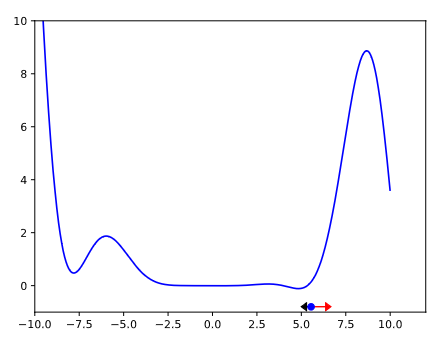

**Chain rule:**

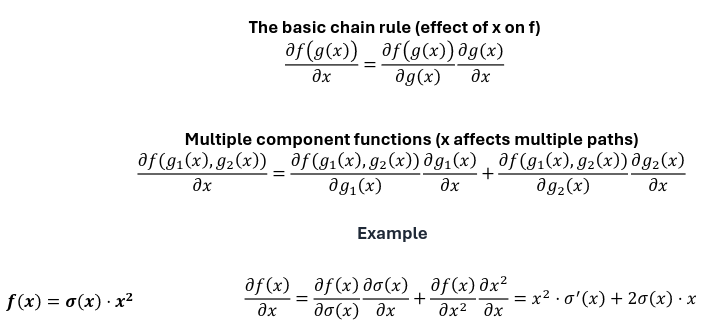

**SGD:** estimate gradient from one example or minibatch (not full dataset).

**4-minute structure:**
1. Training requires gradients.
2. Forward pass computes loss.
3. Backward pass applies chain rule.
4. Backprop computes gradients; optimiser uses them to update.
5. Full-batch vs minibatch vs SGD.

## 2.3 Probabilistic Graphical Models (PGMs)

Graphical representation of large joint probability distribution

**Bayesian network:** DAG + conditional distributions $p(X_i|pa(X_i))$.

**Factorisation:** $p(X_1,\ldots,X_n)=\prod_{i=1}^n p(X_i|pa(X_i))$.

**Why useful:** compact representation, conditional independence, handles missing data.

**4-minute structure:**
1. Graph + local conditionals define joint.
2. Factorisation formula.
3. Conditional independence from graph structure.
4. Inference given evidence.
5. Learning parameters from data.

## 2.4 Maximum Likelihood Learning
Maximum likelihood learning chooses the parameter $θ$ that makes the observed data most probable.

Complete-data case, simple counting
$$\hat\theta = \arg \max_\theta p (data | \theta)$$

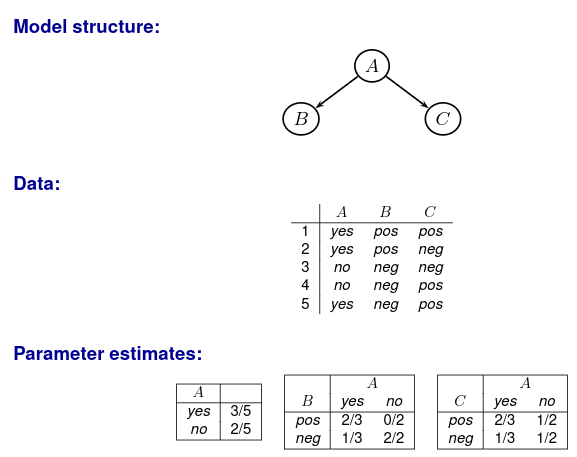

## 2.5 The EM Algorithm

**Purpose:** parameter estimation with latent variables or missing data.

- **E-step:** compute expected sufficient statistics under current parameters (soft assignments).
- **M-step:** update parameters as if expected counts were real.

in general
1. Let $θ^0 = \{θ_{ijk} \}$ be some start estimates $(P (X_i = j | pa(X_i = k) = θ_{ijk} )$.
2. Repeat until convergence:

2.1 E-step: For each variable $X_i$ calculate the table of expected counts:
$$\mathbb{E}[N(X_i, pa(X_i)|D)] = \sum_{d \in D} P(X_i, pa(X_i)|d, \theta^t)$$

2.2 M-step: Use the expected counts as if they were actual counts:
$$\hat\theta^{t+1}_{ijk} = \frac{\mathbb{E}[N(X_i = k, pa(X_i) = j|D)]}{\sum^{|sp(X_i)|}_{k=1} \mathbb{E}[N(X_i = k, pa(X_i) = j|D)]}$$

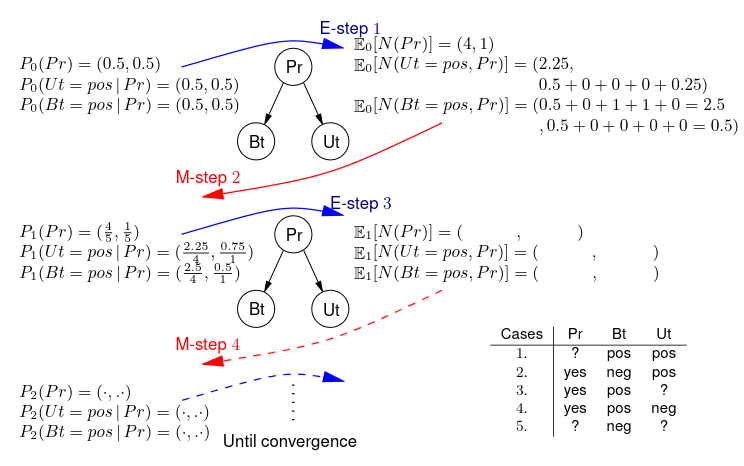

**4-minute structure:**
1. Latent variables / missing data.
2. Marginal likelihood is hard to optimise directly.
3. E-step: soft completion.
4. M-step: re-estimation.
5. Slide example.

## 2.6 Bayesian Learning
Parameter learning amounts to calculating the posterior distribution
over the parameters given the data $D = (x_1,...,x_n)$

**Formula:** $p(\theta|D) = \frac{p(\theta,D)}{p(D)} = \frac{p(\theta)p(D|\theta)}{p(D)}$.


the posterior $p(\theta|D)$ our updated belief about the parameter after seeing the data

the prior $p(\theta)$

the likelihood is $p(D | \theta)$ that means how probable is the observed data, **if** the parameter were $θ$?

the marginal likelihood $p(D)$ 

> start with belief
>
> multiply by how well the data supports each parameter value
>
> normalize

assuming independently sampled data $p(D|\theta) = \prod_{i=1}^N p(x_i|\theta)$

> **Parameter learning** amounts to calculating the posterior distribution over the parameters given the data.

**MLE vs MAP vs Bayesian:**
- MLE: $\hat\theta_{MLE}=\arg\max \log p(D|\theta)$
- MAP: $\hat\theta_{MAP}=\arg\max \log p(D|\theta) + \log p(\theta)$
- Bayesian: keep full posterior $p(\theta|D)$

**Beta-Bernoulli conjugate update:** $\text{Beta}(a+N_1, b+N_0)$.

**4-minute structure:**
1. Prior -> likelihood -> posterior.
2. Compare MLE, MAP, full Bayesian.
3. Conjugacy (Beta-Bernoulli).
4. Posterior predictive distribution.

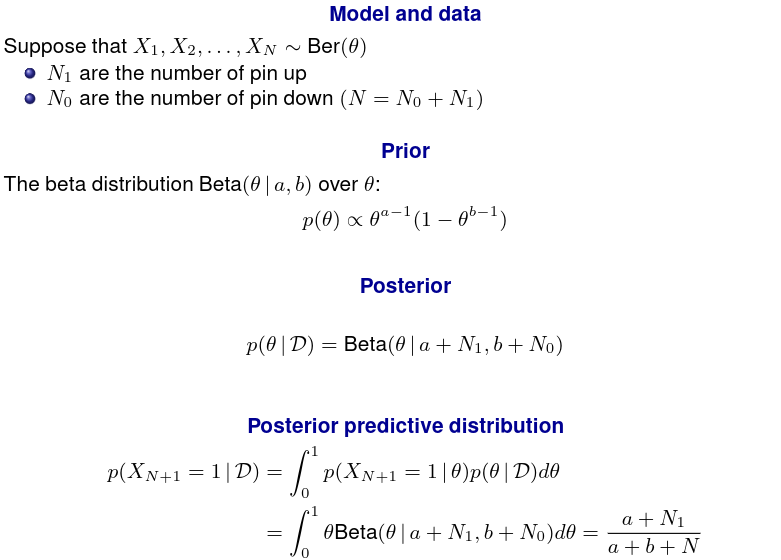

## 2.7 Variational Inference
**What we are working with:** $x$ the observed data and $z$ hidden/latent variables or unknown parameters.

**Problem:** In Bayesian models we often want a posterior $p(z|x) = p(x,z)/p(x)$ is **intractable**(meaning we cannot compute it exactly in a convenient closed form) because $p(x)=\int p(x,z)dz$ is hard.

> Variational Inference says:
> Instead of computing the true posterior $p(z∣x)$ exactly, choose a simpler family of distributions $q_\lambda(z)$, and find the member of that family that is as close as possible to the true posterior. **This transforms the problem a hard inference problem with a _optimization problem_**

to achieve such goal we us the KL divergence which is defined as: 
$$
KL(f || g) = \int f(z) \log\frac{f(z)}{g(z)} dz = \mathbb{E}_f \bigg[ \log\bigg( \frac{f(z)}{g(z)}\bigg)\bigg]
$$ 
**is not symmetric**.

For our case we want ot use it to choose the paramenter $\lambda$ that makes the approximation $q_\lambda (z)$ closer to the posterior. $$\hat q(z) = \arg \min_\lambda KL(q_\lambda || p(z|x))$$

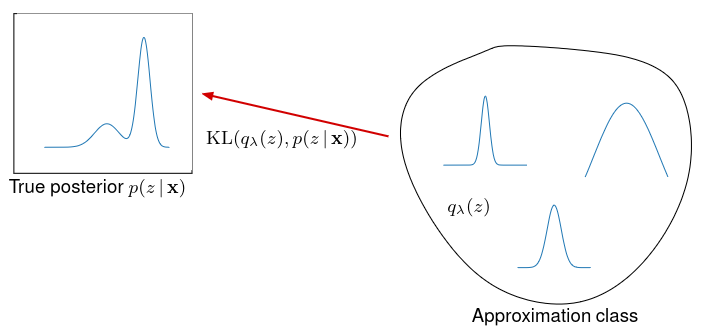

**We still cannot minimize the KL directly** the true posterior is still there and we do not know how to compute it well. So we need to change objective.

![ELBO.png](./2-Thomas/3-Variational%20inference%20in%20probabilistic%20models/ELBO.png)

**ELBO:** $\mathcal{L}(q) = \mathbb{E}_q \left[ \log \frac {p_\theta (z,x)}{q_\lambda (z)}\right]$. Maximising ELBO minimises $\text{KL}(q||p)$.

#### **Mean-field:** 
$q(z)=\prod_i q_i(z_i)$.
Mean field says:

“I will pretend the latent variables are independent in my approximation, even if they are not truly independent in the real posterior.”

So if $z=(z_1,z_2,z_3)$, then instead of using one complicated joint distribution over all three variables, we approximate with: $$q(z_1,z_2,z_3)=q_1(z_1)q_2(z_2)q_3(z_3)$$

**4-minute structure:**
1. Posterior intractability.
2. Introduce variational family $q$.
3. ELBO and KL divergence.
4. Mean-field factorisation.
5. BBVI and probabilistic programming.

### **BBVI:** 
uses score-function gradient estimator.

We want to maximize ELBO by gradient ascent $\mathcal{L}(q) = \mathbb{E}_q \left[ \log \frac {p_\theta (z,x)}{q_\lambda (z)}\right]$

$𝑝_𝜃(𝑧, 𝑥)$ is the joint probability from probabilistic
model

$𝑞_𝜆 (𝑧)$ is variational approximation

Gradient ascent update: $i = i_{t-1} + \eta_t \nabla_i \mathcal{L}(q)_{i_{t-1}}$ **this means that we need the partial derivative of the ELBO function**

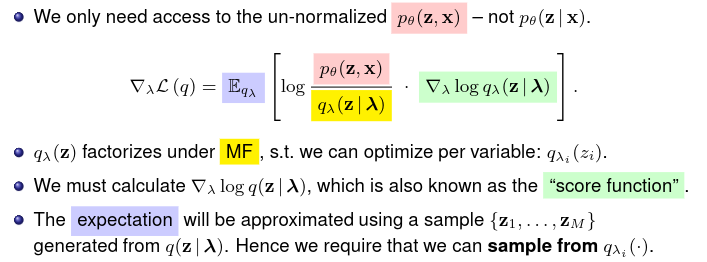

**Probabilistic programming:** specify model, system does inference automatically.

### Probabilistic programming Thumb tack example

# Part 3 – Peter's Topics

## 3.1 Link Prediction with Node Embeddings
Link Prediction = Learning Similarity

We are given a graph: $𝐺 = (𝑉, 𝐸)$

Goal: **Predict whether an unobserved pair of nodes should have an edge**

we will like to have something like this $𝑠 (𝑢, 𝑣) = \text{ similarity score between } 𝑢 \text{ and } 𝑣$

**Encoder-Decoder view:**
- **Encoder:** maps each node to a low-dimensional embedding $z_v$. 
    
    Formally the $ENC: V \to \mathbb{R}^d$ specifically for node embeddings $ENC(v) = Z[v] \text{ where } Z \in \mathbb{R}^{|v|\times d}$

- **Decoder:** predicts link probability from pair $(z_u, z_v)$, typically via dot product.

    Formally $DENC: \mathbb{R}^d \times \mathbb{R}^d \to \mathbb{R}^+$ specifically for reconstruction of the relationships $DEC(ENC(u), ENC(v)) = DEC(z_u, z_v) \approx S[u,v]$

**Learning**, using the encoder decoder view the learning happens by **minimizing** the reconstruction loss, since we want to reconstruct the links. _A nice side effect of this procedure is the prediction of missing links_.
$$L = \sum_{u,v \in D} \ell(DEC(z_u, z_d), S[u,v])$$
Where $ℓ: ℝ × ℝ → ℝ$ is a loss function measuring some kind of a difference between decoded and estimated similarity; $D$ are training node pairs

#### 3.1.1 Matrix factorisation (SVD)
**Dimensionality reduction**

* Decoder / Predictor (dot product): $DEC(z_u, z_v)=z_u^T z_v$
* Loss Function $L = \sum_{(u,v)\in D} ||DEC(z_u, z_v) - S[u,v]||_2^2 \approx || ZZ^T -S||_2^2$

**Matrix Factorization**


Informally, the SVD theorem (Golub and Kahan 1965) states that a given matrix $M$ can be decomposed into a product of three matrices as follows

$$R = U \times \Sigma \times V^T$$

where $U$ and $V$ are called **left** and **right singular vectors** and the values of
the diagonal of $\Sigma$ are called the **singular values**.

> We compute SVD but retain only the $k$ most important features by taking only the first $k$ columns of $U$ and $V^T$

<!-- factorise adjacency $A \approx Z Z^T$ where $Z = U_k \Sigma_k^{1/2}$ (top-k singular vectors). -->

**4-minute structure:**
1. Encoder maps nodes to vectors.
2. Decoder scores pairs (dot product).
3. SVD = direct factorisation of A.
4. Node2Vec = random walks + skip-gram.
5. Evaluate with Hit Rate@K / MRR.

#### 3.1.2 Random walk based approaches
Taking from matrix factorization the in which the that used the dot product of the embeddings as a similarity measure $z_u^T z_v \approx S[u,v]$ we can instead model it as **the probability that u and v co-occur on short random walks over the graphs**. We wan to optimize embeddings to encode such statistics $$z_u^T z_v \propto P_R(v,u)$$

as a loss function that can get very expensive for every node and his neighbors we use

$$\mathcal{L} = \sum_{(u,v) \in D} -\log(\sigma(z_u^Tz_v)) - \gamma \sum_{i=1}^k \log(\sigma(-z_u^T z_k))$$

Where we sample $k$ negative samples from a distribution over set of nodes

<!-- ##### 3.1.2.1 Biased random walk
**Node2Vec** is a random walk-based embedding method that learns node representations by simulating walks on the graph and applying skip-gram models (similar to Word2Vec).

**Core Algorithm:**

1. **Generate random walks**: For each node, perform $r$ random walks of length $l$
   - Walks combine breadth-first (BFS) and depth-first (DFS) exploration controlled by parameters $p$ and $q$
   - Parameter $p$: probability of returning to previous node (DFS tendency)
   - Parameter $q$: probability of exploring outward (BFS tendency)

2. **Learn embeddings via skip-gram**: Treat each walk as a sentence
   - For each node in the walk, predict its neighbors in context window
   - Use this to learn $d$-dimensional embeddings
   - Similar to Word2Vec but applied to graph structure instead of text

3. **Link prediction**: Score edges using dot product of embeddings
   $$p(u,v) = \sigma(\mathbf{X}_{n2v}[u] \cdot \mathbf{X}_{n2v}[v])$$

**Comparison with SVD:**
- SVD: spectral method, captures global graph structure efficiently
- Node2Vec: sampling method, captures neighborhood structure, more flexible but computationally heavier -->


## 3.2 Graph Neural Networks (GNNs)

> Replacing “shallow encoders” by more general encoders
>
> Using both, graph structure and graph attributes/features
>
> Using Neural Network

A Graph Neural Network (GNN) learns a node representation by repeatedly collecting information from neighbors and updating the node embedding. After a few rounds, each node embedding contains information from its local graph neighborhood and node features. In link prediction, those embeddings are then compared (often with a dot product) to decide whether an edge should exist

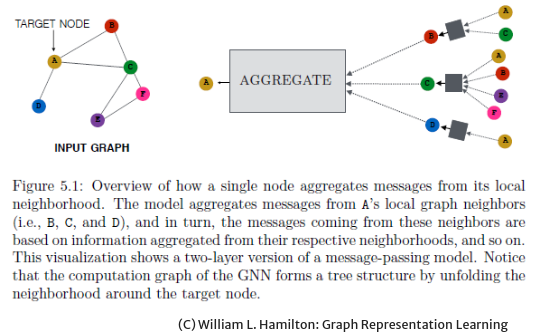

**Message-passing framework:**
$$h_v^{(l+1)} = \text{UPDATE}^{(l)} \left( h_v^{(l)}, \text{AGGREGATE}^{(l)} \left( \{ h_u^{(l)} : \forall u \in N(v) \} \right) \right) = \text{UPDATE}^{(l)}(h^{(l)}_{v}, m^{(l)}_{N(v)})$$

$\text{UPDATE}$ and $\text{AGGREGATE}$ can be arbitrary differentiable functions

$m_{N(v)}$ is a message aggregated from $v$'s neighborhood

$h^{(0)}_{v}$ are a set of input features for all the nodes, $h^{(0)}_{v} = x_u, \forall u \in V$

$$ENC(v) = Z[v] = h^{(L)}_u$$

$L$ is a number of iterations, after which we consider output as a node embeddings

> Still following the same idea of embeddings. **But now also with node features and aggregations**

#### 3.2.1 Basic GNN

A simple GNN layer is written as

$$h_u^{(k+1)} = \sigma \left(W_{self}^{(k)}h_{u}^{(k)} + W^{(k)}_{neigh} \sum_{v \in \mathcal N(u)} h_v^{(k)} + b^{(k)}\right)$$

So the node gets:

* its **own previous representation** $h_{u}^{(k)}$,
* the **sum of neighbor representations**,
* a **linear transformation** via trainable matrices,
* then a **nonlinearity** like ReLU/sigmoid/tanh.

**Basic GNN defined through UPDATE and AGGREGATE**

$$
\text{AGGREGATE}^{(k)} \left( \{ h_v^{(k)} : \forall v \in N(u) \} \right) = m_{\mathcal N(u)} = \sum_{v\in \mathcal N(u)} h_v
$$

$$
\text{UPDATE}(h_u, m_{\mathcal N(u)}) =
\sigma(W_{\text{self}}h_u + W_{\text{neigh}}m_{\mathcal N(u)})
$$

> we have defined it at the node level, but can be defined at the graph level

**Self loops**
Without a self-loop, a node update may depend mostly on neighbors and lose its own information.

So many GNNs add the node to its own neighborhood:

$$
\text{AGGREGATE}^{(k)} \left( \{ h_v^{(k)} : \forall v \in \mathcal N(u)\cup\{u\} \} \right) 
$$

>  instead of adding the update, we add the loops into the input graph

**multiple layers**

A single round of message passing only sees **1-hop neighbors**.  
After $K$ layers, a node representation contains information from its **$K$-hop neighborhood**. Multiple message-passing layers encode the $k$-hop neighborhood and its features.

**Prediction**
the flow is:

The **Encoder** uses message passing to compute node embeddings $z_u$.

The **Decoder** compares two node embeddings to score whether an edge should exist. The slides use a dot-product decoder:

$$
\text{DEC}(h_u^{(K)}, h_v^{(K)}) = {h_u^{(K)}}^T h_v^{(K)}
$$

> **In GNN-based link prediction, message passing computes node embeddings and a decoder (often dot product) predicts whether two nodes should be connected.** 

#### 3.2.2 Generalization with normalization
If we do plain summation then high-degree nodes can produce very large sums, while low-degree nodes produce small sums. That causes instability and makes optimization harder. Creates drastic differences, numerical instability, and optimization problems.

Instead of summing, **average**:

$$
m_{\mathcal N(u)} =
\frac{1}{|\mathcal N(u)|}
\sum_{v\in\mathcal N(u)} h_v
$$

or **symmetric normalization**:

$$
m_{\mathcal N(u)} =
\sum_{v\in\mathcal N(u)}
\frac{h_v}{\sqrt{|\mathcal N(u)|\,|\mathcal N(v)|}}
$$

This normalizes using both the target node degree and the neighbor degree;

#### 3.2.3 Set aggregation
A neighborhood is not an ordered list; it is a **set** of neighbors. That means the aggregation should not depend on the order in which neighbors are listed. The neighborhood aggregation is a **set function** mapping a set of neighbor embeddings to one aggregated vector.
So a good aggregator should be permutation invariant.

Learnable set pooling

$$
m_{\mathcal N(u)} =
\text{MLP}_\theta
\Big(
\sum_{v\in\mathcal N(u)}
\text{MLP}_\phi(h_v)
\Big)
$$

The idea is:

1. transform each neighbor embedding with an MLP,
2. aggregate them,
3. apply another MLP.

> This is a **set pooling** and it acts as a universal set function approximator.

**Why?** A plain sum/mean/max is simple but limited. A learnable set aggregator lets the model learn what kind of neighborhood pattern matters the most.

#### 3.2.3 Attention
Problem with ordinary aggregation $\to$ in sum/mean aggregation, all neighbors are treated equally. But in many graphs, **not all neighbors are equally important**.

So attention introduces a learned weight $\alpha_{u,v}$ for each neighbor $v$ of node $u$:

$$
m_{\mathcal N(u)} = \sum_{v\in\mathcal N(u)} \alpha_{u,v} h_v
$$

where $\alpha_{u,v}$ tells you how important neighbor $v$ is for updating node $u$.

$$
\alpha_{u,v}
=
\frac{
\exp(a^T[Wh_u \oplus Wh_v])
}{
\sum_{v'\in\mathcal N(u)}
\exp(a^T[Wh_u \oplus Wh_{v'}])
}
$$

* $W$ = learnable linear transform
* $a$ = learnable attention vector
* $\oplus$ = concatenation

**multi-head attention** is the standard extension used in Graph Attention Networks (GATs): instead of computing one attention distribution, the model computes **several different attention heads in parallel**.

For head $m$:

$$
m^{(m)}_{\mathcal N(u)} = \sum_{v\in\mathcal N(u)} \alpha^{(m)}_{u,v} W^{(m)} h_v
$$

Then final output is either:

MAA Concatenation

$$
h'_u = m^{(1)}_{\mathcal N(u)} \oplus m^{(2)}_{\mathcal N(u)} \oplus \cdots \oplus m^{(M)}_{\mathcal N(u)}
$$

or

MAA Averaging

$$
h'_u = \frac{1}{M}\sum_{m=1}^{M} m^{(m)}_{\mathcal N(u)}
$$

#### 3.2.4 Generalized Updates
Generalized updates are used to deal with **over-smoothing** and neighborhood influence.

After many message-passing layers, nodes can become too similar to each other. The node-specific information being “washed out,” with aggregated neighborhood messages dominating.

That means(I think...):

* early layers = useful sharing
* too many layers = node identities blur together

Base update:

$$h_u = UPDATE_{base} (h_u, m_{\mathcal N(u)})$$

**Concatenation update**

One idea is to keep the old representation explicitly:

$$
\text{UPDATE}_{\text{concat}}(h_u, m_{\mathcal N(u)})
=
\big[\text{UPDATE}_{\text{basic}}(h_u,m_{\mathcal N(u)}) \oplus h_u\big]
$$

So instead of only using the new mixed representation, you keep the old one too. This helps preserve node-specific information. 

<!-- **B) Linear interpolation / gating**

Another idea is to interpolate between the new message and the old node state:

$$
\text{UPDATE}_{\text{interp}}(h_u,m_{\mathcal N(u)})
=
\alpha_1 \circ \text{UPDATE}_{\text{basic}}(h_u,m_{\mathcal N(u)})
+
\alpha_2 \circ h_u
$$

where $\alpha_1,\alpha_2 \in [0,1]^d$, $\alpha_2=1-\alpha_1$, and $\circ$ is elementwise multiplication. The lecture says these gating vectors can be learned.  -->

**4-minute structure:**
1. Each GNN layer = message + aggregate + update.
2. GCN: normalised sum aggregation.
3. GAT: attention-weighted aggregation.
4. Multi-head = multiple attention mechanisms in parallel.

## 3.3 Node and Graph Classification
Given node features or node neighbors, predict a label/class for a node

Similar to normal classification. But graphs also have edges. Nodes can influence eachother

#### 3.3.1 Iterative Classification

Iterative classification is a method for node classification in graphs where we repeatedly update predictions using both node features and neighborhood information.
We start with the known labels, compute neighborhood-based features, and train a classifier on the labeled nodes.
Then we predict labels for unlabeled nodes, update the neighborhood features using these new predictions, and classify again.
This is useful because connected nodes often have related labels, so neighborhood information helps improve the predictions over several iterations.

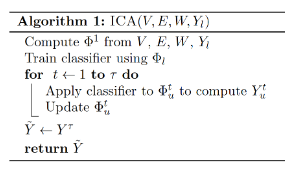

#### 3.3.2 Aggregations for Graph Embeddings

What if our task requires a single representation for the entire graph?

Goal: ${z_v: v \in V} \to z_G$

${z_v: v \in V}$ The **set** of final node embeddings vectors.

$𝐳_𝑣$ for all nodes $𝑣$ in the graph's vertex set $𝒱$

$𝐳_G$ The single, fixed-size target vector representing the entire graph $G$

$$
z_g = \frac{\sum_{u\in V} z_u}{f(|V|)}
$$

There are two variations of this there **sum** pooling and **mean** pooling

but sometimes pooling is not enough 

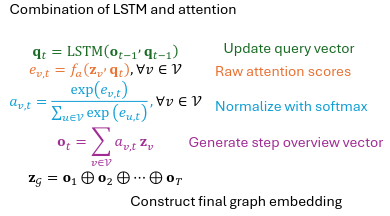

#### 3.3.3 Random Walk Classifications
We split the graph nodes into **labeled** and **unlabeled** sets: $$V = V_l \cup V_u$$.  

The graph is $G=(V,E,W)$, and labels are stored in $Y \in \mathbb{R}^{|V|\times |C|}$.   
We define the **transition matrix** as $$P = D^{-1}W$$, so each row gives transition probabilities.   
Here, $P_{ij} = \Pr(v_i \rightarrow v_j)$ is the probability of moving from node $v_i$ to node $v_j$.   
Labeled nodes are treated as **absorbing**, so once a random walk reaches one, it keeps that label.   
The propagated label scores are computed by $\hat{Y} = P^\infty Y$.   
For one unlabeled node $v_i$ and class $c$: $$\tilde{y}_i[c] = \sum_{j:\,v_j\in V_l} p_{ij}^{\infty}\, y_j[c]$$.   

This sums the probabilities that a random walk from $v_i$ eventually hits labeled nodes of class $c$.   
Finally, predict the class with the largest score: $$\hat{y}_i = \arg\max_{c\in C} \tilde{y}_i[c]$$. 


